<a href="https://colab.research.google.com/github/dharshana-ev06/E_commerce/blob/main/Fraudeye.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    average_precision_score
)

print("FraudEye is ready!")

FraudEye is ready!


In [3]:
uploaded = files.upload()

Saving creditcard.csv.zip to creditcard.csv.zip


In [5]:
import zipfile
import os

print(os.listdir("/content"))

['.config', 'creditcard.csv.zip', 'sample_data']


In [6]:
import zipfile

with zipfile.ZipFile("/content/creditcard.csv.zip", "r") as zip_ref:
    zip_ref.extractall("/content")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [7]:
import pandas as pd

df = pd.read_csv("/content/creditcard.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Dataset shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [8]:
print(df["Class"].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


In [9]:
print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nColumn names:")
print(df.columns.tolist())

Dataset shape: (284807, 31)

Missing values:
0

Duplicate rows:
1081

Column names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [10]:
from sklearn.model_selection import train_test_split

# Input features
X = df.drop("Class", axis=1)

# Target label
y = df["Class"]

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])

print("\nFraud cases in training data:", y_train.sum())
print("Fraud cases in testing data:", y_test.sum())

Training records: 227845
Testing records: 56962

Fraud cases in training data: 394
Fraud cases in testing data: 98


In [11]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("Training FraudEye model...")

model.fit(X_train, y_train)

print("FraudEye model trained successfully!")

Training FraudEye model...
FraudEye model trained successfully!


FRAUDEYE MODEL EVALUATION
-----------------------------------
Accuracy: 0.9995

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
  Fraudulent       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962



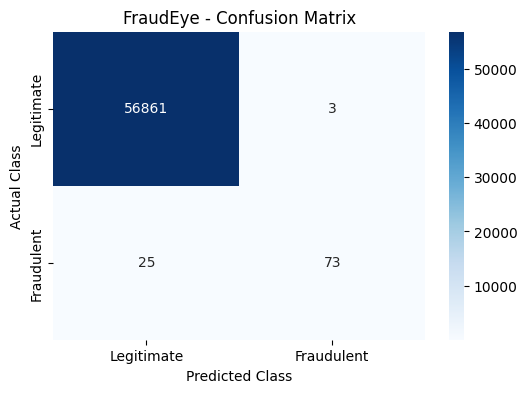

Average Precision: 0.8542


In [12]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    average_precision_score
)
import seaborn as sns
import matplotlib.pyplot as plt

# Predict on unseen test data
y_pred = model.predict(X_test)

# Display evaluation metrics
print("FRAUDEYE MODEL EVALUATION")
print("-" * 35)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Legitimate", "Fraudulent"],
    zero_division=0
))

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraudulent"],
    yticklabels=["Legitimate", "Fraudulent"]
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("FraudEye - Confusion Matrix")
plt.show()

# Average Precision for fraud detection
fraud_scores = model.predict_proba(X_test)[:, 1]
ap = average_precision_score(y_test, fraud_scores)

print("Average Precision:", round(ap, 4))

===== FRAUDEYE MODEL EVALUATION =====
Accuracy: 0.9995

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
  Fraudulent       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962

Average Precision: 0.8542


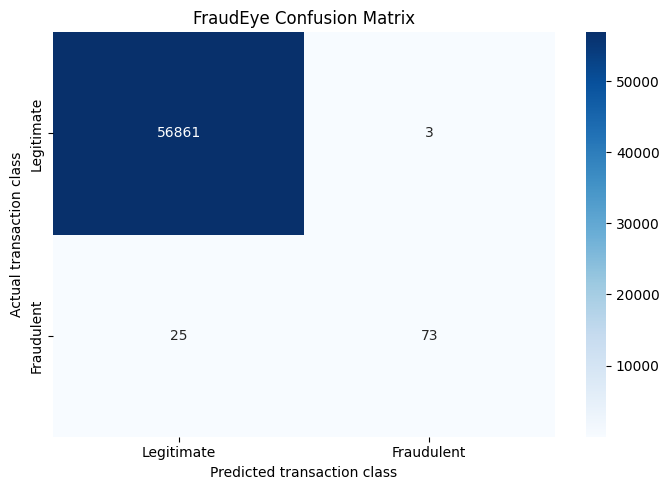

In [13]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    average_precision_score
)
import matplotlib.pyplot as plt
import seaborn as sns

# Predict on unseen test data
y_pred = model.predict(X_test)
y_scores = model.predict_proba(X_test)[:, 1]

# Display evaluation metrics
print("===== FRAUDEYE MODEL EVALUATION =====")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Legitimate", "Fraudulent"],
    zero_division=0
))

print("Average Precision:",
      round(average_precision_score(y_test, y_scores), 4))

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraudulent"],
    yticklabels=["Legitimate", "Fraudulent"]
)
plt.xlabel("Predicted transaction class")
plt.ylabel("Actual transaction class")
plt.title("FraudEye Confusion Matrix")
plt.tight_layout()
plt.show()

In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score
)
import pandas as pd

# Define three algorithms
models = {
    "Logistic Regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        )
    ),

    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": model
}

results = []

for name, clf in models.items():
    print("Evaluating:", name)

    # Train models other than the existing Random Forest
    if name != "Random Forest":
        clf.fit(X_train, y_train)

    # Predict the unseen test data
    predictions = clf.predict(X_test)
    probabilities = clf.predict_proba(X_test)[:, 1]

    results.append({
        "Algorithm": name,
        "Precision": precision_score(
            y_test, predictions, zero_division=0
        ),
        "Recall": recall_score(
            y_test, predictions, zero_division=0
        ),
        "F1-Score": f1_score(
            y_test, predictions, zero_division=0
        ),
        "Average Precision": average_precision_score(
            y_test, probabilities
        )
    })

comparison = pd.DataFrame(results)
print("\n===== MODEL COMPARISON =====")
display(comparison.round(4))

Evaluating: Logistic Regression
Evaluating: Decision Tree
Evaluating: Random Forest

===== MODEL COMPARISON =====


,Algorithm,Precision,Recall,F1-Score,Average Precision
0,Logistic Regression,0.0610,0.9184,0.1144,0.7190
1,Decision Tree,0.6762,0.7245,0.6995,0.4904
2,Random Forest,0.9605,0.7449,0.8391,0.8542


In [15]:
import joblib

joblib.dump(model, "fraudeye_model.pkl")

print("FraudEye model saved successfully!")

FraudEye model saved successfully!
